# The human insula is extensively recruited during human speech

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [3]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')
# text svg

Using notebook 3d backend.


# Fig 1: Whole brain electrodes map to the pial surface

In [4]:
task = [
    'PhonemeSequence',
    'SentenceRep',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]
ref='bipolar'

stats_paths = []
stats_paths.extend(
    BIDSPath(
        root=f'../results/{t}({ref})',
        datatype='HGA',
        suffix='time',  # 注意这里改成 'time'
        check=False,
    ).match()
    for t in task
)

stats_paths = np.concatenate(stats_paths).tolist()

coords = []
for path in tqdm(stats_paths):
    df = pd.read_csv(path)
    coords.append(df)
    
coords = pd.concat(coords)

coords
# rename INS to 'Insula'
coords.loc[coords.roi == 'INS', 'roi'] = 'Insula'

# combine HG to STG
coords.loc[coords.roi == 'HG', 'roi'] = 'STG'

# rename CG to Cingulate cortex
coords.loc[coords.roi == 'PrG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'PoG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'Subcentral', 'roi'] = 'SMC'

coords.head()

100%|██████████| 2254/2254 [00:17<00:00, 126.09it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,Audio,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-04-20 19:00:40.339 (  28.438s) [    7F7D3B99F740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


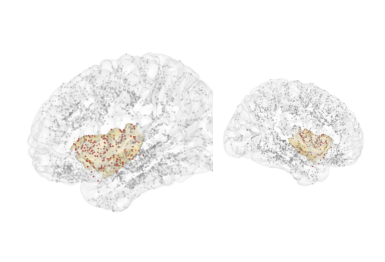

In [5]:
# cvs_avg35_inMNI152 visualization - coordinates already in MNI space from package_HGA.py
coords_unique = coords.drop_duplicates(subset=['channel'])

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# Coordinates are already in cvs_avg35_inMNI152 space (transformed in package_HGA.py)
cord_fsavg = coords_unique[['x', 'y', 'z']].values
insula_mask = coords_unique['roi'].eq('Insula').values

# 计算 fsaverage 和 cvs_avg35_inMNI152 之间的平移向量
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)

# # 应用平移
cord = cord_fsavg + translation

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & (lh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.3,
            )

        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & (rh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.5,
            )

        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

lh_brain.close()
rh_brain.close()

fig.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')

plt.show()

# Plot Anterioro-posterior insula electrodes

In [6]:
# Insula region classification function and visualization
def classify_insula_ap(coords_df, y_threshold=0):
    """
    Classify insula electrodes into AIC (anterior insula cortex) and PIC (posterior insula cortex)
    
    Classification scheme:
    AIC (red team): 
      - All G_insular_short (regardless of coordinates)
      - All S_circular_insula_ant (regardless of coordinates)  
      - All S_circular_insula_sup with Y > 0
      - All S_circular_insula_inf with Y > 0
    
    PIC (blue team):
      - All G_Ins_lg_and_S_cent_ins (regardless of coordinates)
      - All S_circular_insula_sup with Y <= 0
      - All S_circular_insula_inf with Y <= 0
    """
    # Copy data to avoid modifying original data
    coords_classified = coords_df.copy()
    
    # Initialize new classification
    coords_classified['insula_region'] = coords_classified['roi']
    
    # Only process insula electrodes
    insula_mask = coords_classified['roi'] == 'Insula'
    
    # AIC classification conditions
    aic_conditions = (
        (coords_classified['label'].str.contains('G_insular_short')) |
        (coords_classified['label'].str.contains('S_circular_insula_ant')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] > y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] > y_threshold))
    )
    
    # PIC classification conditions  
    pic_conditions = (
        (coords_classified['label'].str.contains('G_Ins_lg_and_S_cent_ins')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] <= y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] <= y_threshold))
    )
    
    # Apply classification
    coords_classified.loc[insula_mask & aic_conditions, 'roi'] = 'AIC'
    coords_classified.loc[insula_mask & pic_conditions, 'roi'] = 'PIC'
    
    return coords_classified

# Apply classification function
coords_ap = classify_insula_ap(coords)

# Statistical results
print(f"AIC electrode count: {len(coords_ap[coords_ap['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(coords_ap[coords_ap['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = coords_ap[coords_ap['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
coords_ap.head()

AIC electrode count: 518080
PIC electrode count: 417344


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z,insula_region
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099,mOccG
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848,OPC
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276,sOccG
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,Audio,sound,Intersection,41.531682,-78.171196,19.605156,Intersection
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923,PhG


In [7]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)

coords_ap[['x','y','z']] = coords_ap[['x','y','z']].values + translation

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


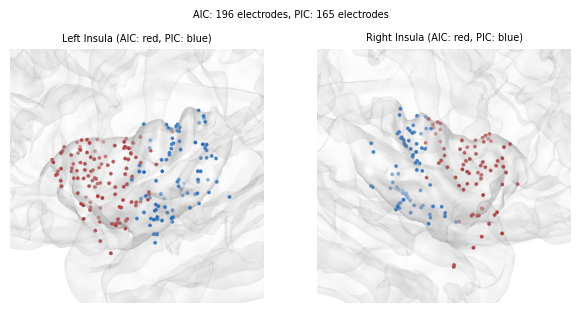

In [ ]:
# 3D Brain with AIC/PIC分区显示 - Electrodes already in cvs_avg35_inMNI152 space
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

# 读取aparc.a2009s labels (cvs_avg35_inMNI152)
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影 (cvs_avg35_inMNI152)
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# 获取分区后的insula电极 - coordinates already in cvs_avg35_inMNI152 space
coords_unique_ap = coords_ap[coords_ap.roi.isin(['AIC', 'PIC'])].drop_duplicates(subset=['channel'])
cord = coords_unique_ap[['x', 'y', 'z']].values  # No translation needed
regions = coords_unique_ap['roi'].values

# 分离左右半球电极
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 定义颜色
aic_color = red
pic_color = blue

# 添加左半球电极（投影到表面）
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_regions = regions[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_proj = lh_pial_coords[lh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = lh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(lh_cord_proj[region_mask])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 添加右半球电极（投影到表面）
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_regions = regions[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_proj = rh_pial_coords[rh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = rh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(rh_cord_proj[region_mask])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, 
                   focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, 
                   focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula (AIC: red, PIC: blue)", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula (AIC: red, PIC: blue)", fontsize=fontsize)

# 添加统计信息
aic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'AIC'])
pic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'PIC'])
plt.suptitle(f"AIC: {aic_count} electrodes, PIC: {pic_count} electrodes", fontsize=fontsize)

lh_brain.close()
rh_brain.close()

# fig.savefig('../img/fig1/fig1_local_electrodes_projected.svg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# TFR on the representation electrode

In [9]:
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'

In [10]:
subject = 'D0088'
pickchannels = coords_ap[(coords_ap.subject==subject) &
          (coords_ap.roi=='AIC')].channel.unique().tolist()
print(pickchannels)

['D0088_LAI5-6', 'D0088_LAI1-2', 'D0088_LAI6-7']


In [34]:
# load all three phases
description = 'Repeat'
phases = ['Stimulus','Delay','Go', 'Response']

tfr_data = {}
stats_data = {}

for phase in phases:
    # Load TFR data
    tfr_path = BIDSPath(
        root=os.path.join(bids_root, 'derivatives', 'tfr'),
        datatype='bipolar',
        suffix='tfr',
        processing=phase,
        extension='.h5',
        check=False
    ).match()[0]
    
    tfr_path = tfr_path.copy().update(subject=subject, description=description)
    tfr_data[phase] = mne.time_frequency.read_tfrs(tfr_path.fpath, verbose=False)
    
    # Load stats data
    stats_path = tfr_path.copy().update(suffix='stats')
    stats = h5py.File(stats_path.fpath, 'r')
    stats_data[phase] = {
        'mask': stats['mask'][()],
        'pvals': stats['pvals'][()]
    }
    stats.close()

i = 2
idx = {phase: tfr_data[phase].ch_names.index(pickchannels[i]) for phase in phases}
tfr_data = {phase: tfr.pick(pickchannels) for phase, tfr in tfr_data.items()}

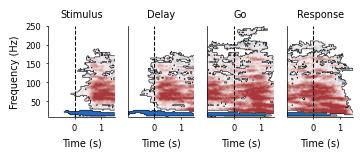

In [ ]:
# Plot TFR for all three phases
freqs = tfr_data['Go'].freqs
times = {phase: tfr_data[phase].times for phase in phases}
ch_data = {phase: tfr_data[phase].get_data()[i] for phase in phases}

p_threshold = 0.05
significant = {phase: (stats_data[phase]['pvals'][idx[phase]] < p_threshold) & 
                        (stats_data[phase]['mask'][idx[phase]] > 0) 
               for phase in phases}

# Use consistent color scaling across all phases
all_data = np.concatenate([ch_data[phase] for phase in phases])
vmin, vmax = np.percentile(all_data, [10, 95])

fig, axes = plt.subplots(1, 4, figsize=(10*cm, 3*cm))

plt.subplots_adjust(wspace=0.2)
for ax, phase in zip(axes, phases):
    
    # Plot TFR
    # im = ax.pcolormesh(
    #     times[phase], freqs, ch_data[phase], 
    #     shading='gouraud', cmap='vlag', rasterized=True,
    #     vmin=vmin, vmax=vmax, alpha=0.2
    # )
    
    # Add significant regions with overlay method
    if np.any(significant[phase]):
        # Create binary mask
        sig_cluster = np.zeros_like(stats_data[phase]['mask'][idx[phase]])
        sig_cluster[significant[phase]] = 1
        
        # Overlay significant regions with reduced alpha for non-significant
        non_sig_data = ch_data[phase].copy()
        non_sig_data[significant[phase]] = np.nan
        
        # Plot significant regions fully opaque
        sig_data = ch_data[phase].copy()
        sig_data[~significant[phase]] = np.nan
        
        ax.pcolormesh(
            times[phase], freqs, sig_data,
            shading='gouraud', cmap='vlag', rasterized=True,
            vmin=vmin, vmax=vmax, alpha=0.9
        )
        
        # Add subtle contour boundary
        ax.contour(times[phase], freqs, sig_cluster,
                levels=[0.5], 
                colors='black',
                alpha=0.8,
                linewidths=0.5,
                linestyles='-')
    
    ax.set_title(phase, fontsize=7)
    ax.set_ylim(10, 250)
    ax.axvline(x=0, color='k', linestyle='--', alpha=1, lw=.75)
    
    # Only show labels on leftmost plot
    if phase == 'Stimulus':
        ax.set_ylabel('Frequency (Hz)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=6, width=.5, length=1.5, which='both')
    plt.setp(ax.spines.values(), linewidth=.5)
    
    # remove y ticks
    if ax != axes[0]:
        ax.set_yticks([])
        
    sns.despine(ax=ax)

fig.savefig('../img/fig1/fig1_example_electrode_tfr.svg', dpi=300, bbox_inches='tight')
plt.show()

# Barplot to show the importance

In [ ]:
coords.head()

,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R


In [ ]:
# 只保留 significant 的电极
# sig = coords

description = 'Repeat'
# sig = coords[(coords['significant']) & (coords['description'] == description)]

sig = coords[(coords['description'] == description) & (coords.significant == True) &
             (~coords.roi.isin(['WM', 'Intersection','Unknown'])) 
             & (coords.phase=='Go')
             ]

# 每个 roi、每个 hemi 的电极数（按 channel 去重）
cnt = (
    sig.groupby(['roi', 'hemi'])['channel']
       .nunique()
       .reset_index(name='n_sig')
)
# 变成行=ROI，列=左右脑 的表
plot_df = (
    cnt.pivot(index='roi', columns='hemi', values='n_sig')
       .fillna(0)
)

# 根据你实际的 hemi 值改列名（例如 'L'/'R' 或 'lh'/'rh'）
# 这里假设是 'L' / 'R'
if 'L' in plot_df.columns and 'R' in plot_df.columns:
    left_col, right_col = 'L', 'R'
else:
    # 例如是 'lh' / 'rh'
    left_col, right_col = 'lh', 'rh'

plot_df = plot_df.rename(columns={left_col: 'Left', right_col: 'Right'})
plot_df['total'] = plot_df[['Left', 'Right']].sum(axis=1)

# 按 total 从大到小排序（和你示意图一样从上到下数量递减）
plot_df = plot_df.sort_values('total', ascending=False)
plot_df = plot_df.head(20)
plot_df.head()

hemi,Left,Right,unknown,total
roi,,,,
Insula,46.0,33.0,0.0,79.0
SMC,49.0,29.0,0.0,78.0
STS,38.0,29.0,0.0,67.0
STG,28.0,18.0,0.0,46.0
CG,18.0,18.0,0.0,36.0


In [ ]:
# ============================================================
# 按 significant 占比排序 + 多种可视化方式
# ============================================================

description = 'Repeat'
phases = ['Stimulus', 'Go', 'Response']

# 基础筛选（包含所有 phase）
base = coords[
    (coords['description'] == description) &
    (~coords.roi.isin(['WM', 'Intersection', 'Unknown'])) &
    (coords['phase'].isin(phases))
].copy()

# 每个 channel：只要任意 phase significant=True 就算 overall significant
chan_any = (
    base.groupby('channel', as_index=False)
        .agg(
            roi=('roi', 'first'),
            hemi=('hemi', 'first'),
            any_phase_sig=('significant', 'any')  # 关键：任意phase显著即算显著
        )
)

# 然后在 ROI×hemi 上统计
stats_df = (
    chan_any.groupby(['roi', 'hemi'], as_index=False)
            .agg(
                n_sig=('any_phase_sig', 'sum'),
                n_total=('channel', 'nunique')
            )
)

# 计算占比
stats_df['ratio'] = stats_df['n_sig'] / stats_df['n_total']

# 汇总到 roi 级别
roi_stats = (
    stats_df.groupby('roi')
    .agg(
        n_sig_total=('n_sig', 'sum'),
        n_total=('n_total', 'sum')
    )
    .reset_index()
)
roi_stats['ratio'] = roi_stats['n_sig_total'] / roi_stats['n_total']
roi_stats = roi_stats.sort_values('n_sig_total', ascending=False)

# 同时保留左右脑信息用于后续绘图
plot_ratio_df = stats_df.pivot(index='roi', columns='hemi', values='ratio').fillna(0)
plot_count_df = stats_df.pivot(index='roi', columns='hemi', values='n_sig').fillna(0)
plot_total_df = stats_df.pivot(index='roi', columns='hemi', values='n_total').fillna(0)

# 重命名列
for df in [plot_ratio_df, plot_count_df, plot_total_df]:
    if 'L' in df.columns and 'R' in df.columns:
        df.rename(columns={'L': 'Left', 'R': 'Right'}, inplace=True)

picks=['SMC','STG','MFG','SMG',
       'Insula','AG','IFG','STS','MTG',
       'SFG',
      ]
# 先按 picks 过滤，再取 head
roi_stats = roi_stats[roi_stats.roi.isin(picks)]

# 按总占比排序
plot_ratio_df['total_ratio'] = roi_stats.set_index('roi')['ratio']
plot_ratio_df = plot_ratio_df.loc[roi_stats['roi']]
plot_count_df = plot_count_df.reindex(roi_stats['roi'])
plot_total_df = plot_total_df.reindex(roi_stats['roi'])

print("按 significant 占比排序的 ROI:")
display(roi_stats.head(40))

按 significant 占比排序的 ROI:


,roi,n_sig_total,n_total,ratio
22,Insula,136,251,0.541833
46,STS,107,307,0.348534
42,SMC,104,230,0.452174
45,STG,77,144,0.534722
27,MFG,27,107,0.252336
29,MTG,27,171,0.157895
17,IFG,24,84,0.285714
43,SMG,20,54,0.370370
40,SFG,12,108,0.111111
0,AG,10,33,0.303030


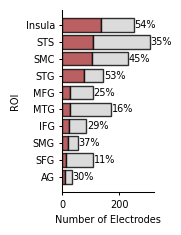

In [ ]:
# ============================================================
# 可视化 6: 堆叠条形图 - 显示 significant vs non-significant
# ============================================================

fig, ax = plt.subplots(figsize=(3*cm, 6*cm))

rois = roi_stats['roi'].values
n_sig = roi_stats['n_sig_total'].values
n_total = roi_stats['n_total'].values
n_nonsig = n_total - n_sig

ax.barh(rois, n_sig, color=red, edgecolor='black', label='Significant', alpha=0.8, height=0.8,)
ax.barh(rois, n_nonsig, left=n_sig, color='lightgray', edgecolor='black', label='Non-significant', alpha=0.8, height=0.8)

# 在条形右侧标注占比
for i, (roi, sig, total) in enumerate(zip(rois, n_sig, n_total)):
    ratio = sig / total * 100
    ax.text(total + 2, roi, f'{ratio:.0f}%', va='center', fontsize=7)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
ax.set_xlabel('Number of Electrodes', fontsize=fontsize)
ax.set_ylabel('ROI', fontsize=fontsize)

sns.despine()
ax.invert_yaxis()
# ax.legend(loc='lower right', fontsize=6)
fig.savefig('../img/fig1/fig1_insula_stats.svg', dpi=300, bbox_inches='tight')
plt.show()

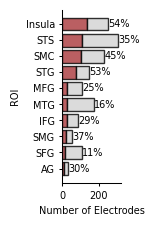

In [ ]:
# ============================================================
# 可视化: 按 significant 电极数目排序的堆叠条形图
# ============================================================

# 按 significant 电极数目排序
roi_stats_by_count = roi_stats.sort_values('n_sig_total', ascending=False)

fig, ax = plt.subplots(figsize=(4*cm, 6*cm))

rois = roi_stats_by_count['roi'].values
n_sig = roi_stats_by_count['n_sig_total'].values
n_total = roi_stats_by_count['n_total'].values
n_nonsig = n_total - n_sig

# 堆叠条形图
ax.barh(rois, n_sig, color=red, edgecolor='black', label='Significant', alpha=0.8, height=0.8,)
ax.barh(rois, n_nonsig, left=n_sig, color='lightgray', edgecolor='black', label='Non-significant', alpha=0.8, height=0.8)

# 在条形右侧标注占比
for i, (roi, sig, total) in enumerate(zip(rois, n_sig, n_total)):
    ratio = sig / total * 100
    ax.text(total + 2, roi, f'{ratio:.0f}%', va='center', fontsize=7)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
ax.set_xlabel('Number of Electrodes', fontsize=fontsize)
ax.set_ylabel('ROI', fontsize=fontsize)

sns.despine()
ax.invert_yaxis()
# ax.legend(loc='lower right', fontsize=6)
plt.tight_layout()
plt.show()

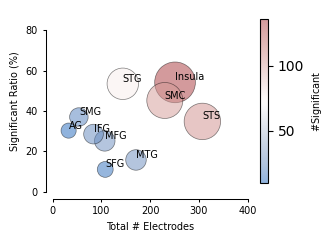

In [ ]:
rois = roi_stats['roi'].values
n_total = roi_stats['n_total'].values
ratio_pct = roi_stats['ratio'].values * 100

fig, ax = plt.subplots(figsize=(8*cm, 6*cm))

n_sig = roi_stats['n_sig_total'].values
sizes = (n_sig / max(n_sig.max(), 1)) * 800 + 60

sc = ax.scatter(
    n_total,
    ratio_pct,
    s=sizes,
    c=n_sig,
    cmap='vlag',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5,
)

for roi, x, y in zip(rois, n_total, ratio_pct):
    ax.text(x, y, roi, fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Total # Electrodes', fontsize=fontsize)
ax.set_ylabel('Significant Ratio (%)', fontsize=fontsize)
ax.set_ylim(0, 90)
ax.set_xlim(0, 400)
sns.despine(offset=5, trim=True)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9)
cbar.set_label(r'$\# \mathrm{Significant}$', fontsize=7)

fig.savefig('../img/fig1/fig1_insula_stats.svg', dpi=300, bbox_inches='tight')
plt.show()

# Just the sustained activity

In [ ]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 2254/2254 [00:16<00:00, 133.73it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [ ]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

In [14]:
# Whole-brain maintenance HGA (Delay 0–0.5, mask=True)
# Color/alpha/size all mapped by HGA using the single `reds` colormap
import pyvista as pv
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

# 1) Maintenance mask & aggregation (mean per channel)
maint_mask = (
    # (HGAs['task']=='LexicalDelay') &
    (HGAs['phase'] == 'response') &
    (HGAs['description'] == 'Repeat') &
    (HGAs['time'] >= -0.5) &
    (HGAs['time'] <= 0.5) &
    (HGAs['mask'] == True)
)

maint = HGAs[maint_mask]
maint_spatial = (
    maint.groupby('channel')
    .agg({
        'value': 'mean',
        'x': 'first',
        'y': 'first',
        'z': 'first',
        'roi': 'first',
        'label': 'first',
        'phase': 'first',
        'hemi': 'first',
        'subject': 'first',
        'description': 'first',
        'task': 'first'
    })
    .reset_index()
    .rename(columns={'value': 'HGA'})
)

maint_spatial = maint_spatial[~maint_spatial.roi.isin(
    ['Intersection', 'OPC','Cun','CollatAnt',
     'PhG','FuG','LinGs','Hipp','Central','mOccG',
     'LinG','PCuns','PCun','GRect','FuGs','Amyg','Calcarine',
     'Put','OccS','PCun','VDC','LatV','InfLatV','iOccGs',
     'Intersection(unknown)','Thal','BrainStem(unknown)',
     'Paracentral','PCC','Sylvian','OFCs'
     ]
)]

# maint_spatial = maint_spatial[maint_spatial.roi.isin(['AIC'])]
maint_spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0005_LTG14-15,1.041372,-68.886726,-28.295294,0.243498,STG,ctx_lh_G_temp_sup-Lateral,response,L,D0005,Repeat,SentenceRep
1,D0005_LTG15-16,1.001534,-69.639740,-38.151283,4.609248,STG,ctx_lh_G_temp_sup-Lateral,response,L,D0005,Repeat,SentenceRep
2,D0005_LTG30-31,0.347045,-55.770381,-38.615740,-23.875112,ITG,ctx_lh_G_temporal_inf,response,L,D0005,Repeat,SentenceRep
3,D0005_LTG4-5,0.424393,-63.895071,-1.988314,1.863490,STG,ctx_lh_G_temp_sup-Lateral,response,L,D0005,Repeat,SentenceRep
5,D0005_LTG6-7,0.283923,-67.026288,-22.001253,12.457651,SMG,ctx_lh_G_pariet_inf-Supramar,response,L,D0005,Repeat,SentenceRep


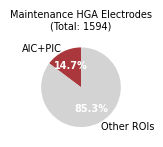

In [15]:
# Pie chart: AIC+PIC (Insula) vs Other ROIs proportion
roi_counts = maint_spatial['roi'].value_counts()

# Calculate AIC+PIC count and Other count
aic_count = roi_counts.get('AIC', 0)
pic_count = roi_counts.get('PIC', 0)
insula_count = aic_count + pic_count
other_count = roi_counts.drop(['AIC', 'PIC'], errors='ignore').sum()

# Data for pie chart
labels = ['AIC+PIC', 'Other ROIs']
sizes = [insula_count, other_count]
colors = [red, 'lightgray']

fig, ax = plt.subplots(figsize=(4*cm, 4*cm))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 7}
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(7)

ax.set_title(f'Maintenance HGA Electrodes\n(Total: {insula_count + other_count})', fontsize=7)

plt.tight_layout()
plt.show()

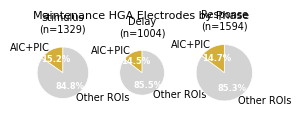

In [28]:
# Three-phase pie charts: AIC+PIC vs Other ROIs with size proportional to electrode count

# Define phases and their time windows
phase_configs = {
    'stimulus': {'phase': 'stimulus', 'time_min': 0, 'time_max': 1},
    'delay': {'phase': 'delay', 'time_min': 0, 'time_max': 1},
    'response': {'phase': 'response', 'time_min': -0.5, 'time_max': 0.5}
}

# ROI exclusions (same as Cell 25)
exclude_rois = ['Intersection', 'OPC', 'Cun', 'CollatAnt',
                'PhG', 'FuG', 'LinGs', 'Hipp', 'Central', 'mOccG',
                'LinG', 'PCuns', 'PCun', 'GRect', 'FuGs', 'Amyg', 'Calcarine',
                'Put', 'OccS', 'VDC', 'LatV', 'InfLatV', 'iOccGs',
                'Intersection(unknown)', 'Thal', 'BrainStem(unknown)',
                'Paracentral', 'PCC', 'Sylvian', 'OFCs']

# Process each phase
phase_data = {}
max_count = 0

for phase_name, config in phase_configs.items():
    # Filter data
    mask = (
        (HGAs['phase'] == config['phase']) &
        (HGAs['description'] == 'Repeat') &
        (HGAs['time'] > config['time_min']) &
        (HGAs['time'] < config['time_max']) &
        (HGAs['mask'] == True)
    )
    
    phase_df = HGAs[mask]
    
    # Get unique channels and their ROIs
    spatial = (
        phase_df.groupby('channel')
        .agg({'roi': 'first'})
        .reset_index()
    )
    
    # Exclude unwanted ROIs
    spatial = spatial[~spatial.roi.isin(exclude_rois)]
    
    # Count ROIs
    roi_counts = spatial['roi'].value_counts()
    aic_count = roi_counts.get('AIC', 0)
    pic_count = roi_counts.get('PIC', 0)
    insula_count = aic_count + pic_count
    other_count = roi_counts.drop(['AIC', 'PIC'], errors='ignore').sum()
    total_count = insula_count + other_count
    
    phase_data[phase_name] = {
        'insula': insula_count,
        'other': other_count,
        'total': total_count
    }
    
    max_count = max(max_count, total_count)

# Calculate subplot widths based on electrode counts
# Use area proportionality: width proportional to sqrt(count)
widths = [np.sqrt(phase_data[phase]['total'] / max_count) for phase in ['stimulus', 'delay', 'response']]

# Create figure with variable-width subplots
fig = plt.figure(figsize=(7.5*cm, 3*cm))
gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.3)

for idx, (phase_name, data) in enumerate(phase_data.items()):
    ax = fig.add_subplot(gs[idx])
    
    # Prepare pie data
    sizes = [data['insula'], data['other']]
    labels = ['AIC+PIC', 'Other ROIs']
    colors = [insula_color, 'lightgray']
    
    # Create pie chart - now the subplot size itself varies
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 7},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'}
    )
    
    # Style percentage text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)
    
    # Set title with phase name and count
    ax.set_title(f'{phase_name.capitalize()}\n(n={data["total"]})', fontsize=7)

plt.suptitle('Maintenance HGA Electrodes by Phase', fontsize=8, y=1.02)
fig.savefig(f'../img/fig1/chn_number_phase.svg', dpi=300, bbox_inches='tight')
plt.show()

2026-04-04 10:28:49.020 ( 163.977s) [    7FEC93D45740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


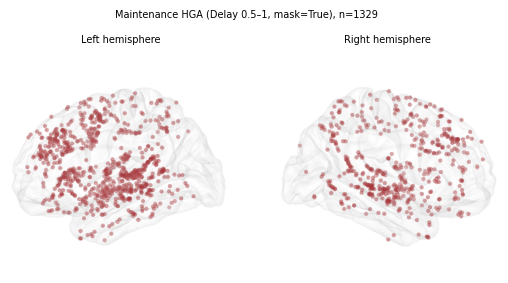

In [ ]:

coords = maint_spatial[['x', 'y', 'z']].values
hga_values = maint_spatial['HGA'].values

# 2) Normalization and mapping
vmin, vmax = 0, np.percentile(hga_values, 98)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
alpha_min, alpha_max = 0.1, 1.0
size_min, size_max = 5, 25


def hga_to_size(hga):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)


def hga_to_alpha(hga):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return alpha_min + normalized * (alpha_max - alpha_min)

# 3) Load fsaverage surfaces and KD-trees
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 4) Helper to add electrodes (project to pial, map color/alpha/size)
def add_electrodes(brain, coords, hga_vals, tree, pial_coords):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    for pt, hga in zip(coords_proj, hga_vals):
        rgb = reds(norm(hga))[:3]
        # alpha = hga_to_alpha(hga)
        # size = hga_to_size(hga)
        alpha=0.5
        size = 15
        rgb = red
        cloud = pv.PolyData(pt[None, :])
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=rgb,
            opacity=alpha,
            lighting=False,
        )

# 5) Brain setup (both hemispheres, light cortex)
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# 6) Plot all maintenance electrodes (single colormap/alpha/size mapping)
if mask_lh.any():
    add_electrodes(lh_brain, coords[mask_lh], hga_values[mask_lh], lh_tree, lh_pial_coords)
if mask_rh.any():
    add_electrodes(rh_brain, coords[mask_rh], hga_values[mask_rh], rh_tree, rh_pial_coords)

lh_brain.show_view(azimuth=180, elevation=90, distance=350)
rh_brain.show_view(azimuth=0, elevation=90, distance=350)

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left hemisphere", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right hemisphere", fontsize =fontsize)

plt.suptitle(f"Maintenance HGA (Delay 0.5–1, mask=True), n={len(maint_spatial)}", fontsize=fontsize)
lh_brain.close()
rh_brain.close()

# fig.savefig(f'../img/misc/maintenance_hga_first.svg', dpi=300, bbox_inches='tight')

plt.show()

## Subject brain

In [62]:
sub = 'D0064'
subid = 'D64'
sub_coords_roi = coords[coords.subject==sub].groupby('channel').first()
sub_coords_roi['roi'] = sub_coords_roi.apply(classify_insula_row, axis=1, y_threshold=0)

sub_coords_roi.head()

,time,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
channel,,,,,,,,,,,,,,
D0064_L2ST1-2,-1.0,0.051853,False,Intersection,L,D0064,Repeat,PhonemeSequence,Audio,sound,Intersection,-46.518464,-25.342449,7.909901
D0064_L2ST2-3,-1.0,-0.026979,False,Intersection,L,D0064,Repeat,PhonemeSequence,Audio,sound,Intersection,-49.343782,-25.080855,7.911814
D0064_L2ST3-4,-1.0,0.134039,False,Intersection,L,D0064,Repeat,PhonemeSequence,Audio,sound,Intersection,-52.068252,-24.827179,7.851718
D0064_L2ST4-5,-1.0,0.039046,False,STG,L,D0064,Repeat,PhonemeSequence,Audio,sound,ctx_lh_G_temp_sup-Plan_tempo,-54.691824,-24.581475,7.729620
D0064_L2ST6-7,-1.0,0.032143,False,STG,L,D0064,Repeat,PhonemeSequence,Audio,sound,ctx_lh_G_temp_sup-Plan_tempo,-60.342452,-24.058286,7.733447


In [23]:

bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'
epoch_paths = BIDSPath(
        root=bids_root + f"derivatives/epoch(bipolar)",
        subject=sub,
        suffix='highgamma',
        datatype='epoch(band)(zscore)',
        extension=".h5",
        check=False,
    )

epoch_path = epoch_paths.match()[0]
epochs = mne.read_epochs(epoch_path, preload=True)
montage = epochs.get_montage()
subj_coords = montage.get_positions()['ch_pos']
subj_coords = pd.DataFrame(subj_coords).T
subj_coords.columns = ['x', 'y', 'z']
subj_coords[['x','y','z']] *= 1000

# Join with ROI labels from sub_coords
subj_coords = subj_coords.join(sub_coords_roi[['roi']], how='left')

# Filter insula electrodes: AIC and PIC
aic_coords = subj_coords[subj_coords['roi'] == 'AIC'][['x', 'y', 'z']].values
pic_coords = subj_coords[subj_coords['roi'] == 'PIC'][['x', 'y', 'z']].values

print(f"AIC electrodes: {len(aic_coords)}, PIC electrodes: {len(pic_coords)}")

Reading /cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0064/epoch(band)(zscore)/sub-D0064_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5 ...
    Found the data of interest:
        t =   -1000.00 ...    1492.19 ms
        0 CTF compensation matrices available
Not setting metadata
160 matching events found
No baseline correction applied
0 projection items activated


AIC electrodes: 3, PIC electrodes: 0


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3468587/4136273637.py:12: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0064/epoch(band)(zscore)/sub-D0064_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epoch_path, preload=True)


Strips containing insula electrodes: ['D0064_LAI']
Total electrodes in insula strips: 15
  AIC: 3, PIC: 0, Other: 12
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot


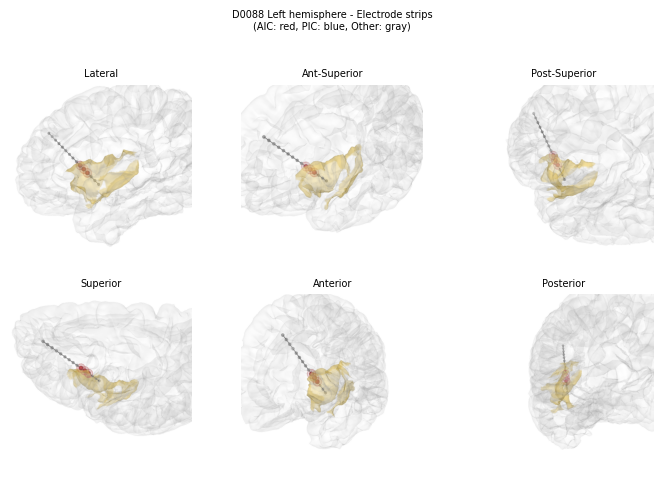

In [44]:
import re

info = epochs.info

# --- 1. Extract strip prefix from channel names ---
def get_strip_prefix(ch_name):
    """Extract strip prefix: D0088_LAI1-2 -> D0088_LAI"""
    # Split on first underscore to separate subject ID from electrode name
    parts = ch_name.split('_', 1)
    if len(parts) == 2:
        subj, elec = parts
        # Extract alphabetic prefix from electrode part
        alpha_prefix = re.match(r'[A-Za-z]+', elec)
        if alpha_prefix:
            return f"{subj}_{alpha_prefix.group()}"
    return ch_name

subj_coords['strip'] = [get_strip_prefix(ch) for ch in subj_coords.index]

# --- 2. Find strips containing at least one AIC or PIC electrode ---
insula_channels = subj_coords[subj_coords['roi'].isin(['AIC', 'PIC'])].index
insula_strips = subj_coords.loc[insula_channels, 'strip'].unique()
print(f"Strips containing insula electrodes: {insula_strips}")

insula_strips = np.delete(insula_strips, np.where(insula_strips == 'D0088_LTAS'))
# --- 3. Get all electrodes belonging to those strips ---
strip_mask = subj_coords['strip'].isin(insula_strips)
strip_electrodes = subj_coords[strip_mask].copy()
print(f"Total electrodes in insula strips: {len(strip_electrodes)}")
print(f"  AIC: {(strip_electrodes['roi']=='AIC').sum()}, "
      f"PIC: {(strip_electrodes['roi']=='PIC').sum()}, "
      f"Other: {(~strip_electrodes['roi'].isin(['AIC','PIC'])).sum()}")

# --- 4. Brain visualization ---
lh_brain = Brain(
    subid, subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# Add insula labels
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

labels = mne.read_labels_from_annot(
    subject=subid, parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)

# --- 5. Plot electrodes by strip, colored by AIC/PIC/other ---
color_map = {'AIC': red, 'PIC': blue}
default_color = 'gray'
LABEL_RADIUS = 3  # 3mm radius used for ROI labeling

for strip_name in insula_strips:
    strip_df = strip_electrodes[strip_electrodes['strip'] == strip_name]
    coords_arr = strip_df[['x', 'y', 'z']].values
    rois = strip_df['roi'].values
    
    for i, (coord, roi) in enumerate(zip(coords_arr, rois)):
        color = color_map.get(roi, default_color)
        alpha = 1 if roi in ('AIC', 'PIC') else 0.5
        size = 0.3 if roi in ('AIC', 'PIC') else 0.2
        lh_brain.add_foci(
            coord[np.newaxis, :],
            scale_factor=size,
            color=color,
            alpha=alpha,
        )
        # Add wireframe sphere only for AIC/PIC electrodes
        if roi in ('AIC', 'PIC'):
            radius_sphere = pv.Sphere(
                radius=LABEL_RADIUS, center=coord,
                theta_resolution=12, phi_resolution=12
            )
            lh_brain._renderer.plotter.add_mesh(
                radius_sphere, style='wireframe', color=color,
                line_width=0.5, opacity=0.25
            )
    
    # Draw lines connecting electrodes in each strip
    if len(coords_arr) > 1:
        for j in range(len(coords_arr) - 1):
            line = pv.Line(coords_arr[j], coords_arr[j + 1])
            lh_brain._renderer.plotter.add_mesh(
                line, color='black', line_width=3, opacity=0.7
            )

# --- 6. Focus view on insula ---
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/{subid}/surf/lh.pial")

def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)

# --- 7. Multiple views from different angles ---
views = [
    {'azimuth': 180, 'elevation': 90,  'label': 'Lateral'},
    {'azimuth': 150, 'elevation': 60,  'label': 'Ant-Superior'},
    {'azimuth': 210, 'elevation': 60,  'label': 'Post-Superior'},
    {'azimuth': 180, 'elevation': 20,  'label': 'Superior'},
    {'azimuth': 120, 'elevation': 85,  'label': 'Anterior'},
    {'azimuth': 240, 'elevation': 85,  'label': 'Posterior'},
]

nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(18*cm, 12*cm))

for ax, view in zip(axes.flat, views):
    lh_brain.show_view(
        azimuth=view['azimuth'], elevation=view['elevation'],
        distance=250, focalpoint=lh_insula_center
    )
    ax.imshow(lh_brain.screenshot(mode="rgb"))
    ax.axis("off")
    ax.set_title(view['label'], fontsize=fontsize)

fig.suptitle("D0088 Left hemisphere - Electrode strips\n(AIC: red, PIC: blue, Other: gray)",
             fontsize=fontsize, y=1.02)
lh_brain.close()
plt.tight_layout()
plt.show()

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot


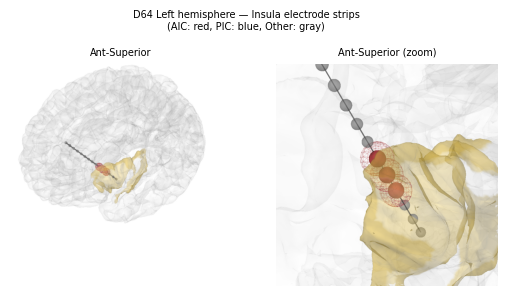

In [61]:
# --- Version 2: Ant-Superior focused view with zoom-in ---
import re

info = epochs.info

# --- 1. Extract strip prefix from channel names ---
def get_strip_prefix(ch_name):
    """Extract strip prefix: D0088_LAI1-2 -> D0088_LAI"""
    parts = ch_name.split('_', 1)
    if len(parts) == 2:
        subj, elec = parts
        alpha_prefix = re.match(r'[A-Za-z]+', elec)
        if alpha_prefix:
            return f"{subj}_{alpha_prefix.group()}"
    return ch_name

subj_coords['strip'] = [get_strip_prefix(ch) for ch in subj_coords.index]

# --- 2. Find strips containing at least one AIC or PIC electrode ---
insula_channels = subj_coords[subj_coords['roi'].isin(['AIC', 'PIC'])].index
insula_strips = subj_coords.loc[insula_channels, 'strip'].unique()
insula_strips = np.delete(insula_strips, np.where(insula_strips == 'D0088_LTAS'))

strip_mask = subj_coords['strip'].isin(insula_strips)
strip_electrodes = subj_coords[strip_mask].copy()

# --- Helper: build the Brain with electrodes ---
def build_insula_brain(hemi='lh', cortex_alpha=0.1):
    brain = Brain(
        subid, subjects_dir=recon_dir, surf="pial",
        hemi=hemi, background="white", show=False,
        cortex=(0.9, 0.9, 0.9), alpha=cortex_alpha, size=(800, 800)
    )
    
    insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                       'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
    
    labs = mne.read_labels_from_annot(
        subject=subid, parc='aparc.a2009s',
        surf_name='pial', hemi='both', subjects_dir=recon_dir
    )
    
    for lab in labs:
        if any(pattern in lab.name for pattern in insula_patterns):
            if lab.hemi == 'lh':
                brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)
    
    # Plot electrodes by strip (all on lh)
    color_map = {'AIC': red, 'PIC': blue}
    LABEL_RADIUS = 3
    foci_hemi = 'lh' if hemi == 'both' else None
    
    for strip_name in insula_strips:
        strip_df = strip_electrodes[strip_electrodes['strip'] == strip_name]
        coords_arr = strip_df[['x', 'y', 'z']].values
        rois = strip_df['roi'].values
        
        for i, (coord, roi) in enumerate(zip(coords_arr, rois)):
            color = color_map.get(roi, 'gray')
            alpha = 1 if roi in ('AIC', 'PIC') else 0.5
            size = 0.3 if roi in ('AIC', 'PIC') else 0.2
            foci_kwargs = dict(
                coords=coord[np.newaxis, :], scale_factor=size,
                color=color, alpha=alpha,
            )
            if foci_hemi:
                foci_kwargs['hemi'] = foci_hemi
            brain.add_foci(**foci_kwargs)
            if roi in ('AIC', 'PIC'):
                radius_sphere = pv.Sphere(
                    radius=LABEL_RADIUS, center=coord,
                    theta_resolution=12, phi_resolution=12
                )
                brain._renderer.plotter.add_mesh(
                    radius_sphere, style='wireframe', color=color,
                    line_width=0.5, opacity=0.5
                )
        
        if len(coords_arr) > 1:
            for j in range(len(coords_arr) - 1):
                line = pv.Line(coords_arr[j], coords_arr[j + 1])
                brain._renderer.plotter.add_mesh(
                    line, color='black', line_width=5, opacity=0.6
                )
    
    return brain, labs, insula_patterns

# --- Build brains ---
# Panel 1: both hemispheres, very transparent cortex
both_brain, labels, insula_patterns = build_insula_brain(hemi='both', cortex_alpha=0.1)
# Panel 2: lh only, less transparent cortex for zoom
zoom_brain, _, _ = build_insula_brain(hemi='lh', cortex_alpha=0.05)

# --- Compute insula center ---
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/{subid}/surf/lh.pial")

def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)

# --- Compute AIC electrode center for tighter zoom ---
aic_electrodes = strip_electrodes[strip_electrodes['roi'] == 'AIC']
if len(aic_electrodes) > 0:
    aic_center = aic_electrodes[['x', 'y', 'z']].values.mean(axis=0)
else:
    aic_center = lh_insula_center

# --- Create figure: 2 panels ---
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm),
                         gridspec_kw={'width_ratios': [1, 1]})

# Panel 1: Ant-Superior — both hemispheres
both_brain.show_view(azimuth=150, elevation=60, distance=350, focalpoint=lh_insula_center)
axes[0].imshow(both_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Ant-Superior", fontsize=fontsize)
both_brain.close()

# Panel 2: Zoomed-in — lh only, more opaque cortex
zoom_brain.show_view(azimuth=120, elevation=85, distance=100, focalpoint=aic_center)
axes[1].imshow(zoom_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Ant-Superior (zoom)", fontsize=fontsize)
zoom_brain.close()

fig.suptitle(f"{subid} Left hemisphere — Insula electrode strips\n(AIC: red, PIC: blue, Other: gray)",
             fontsize=fontsize, y=1.02)

fig.savefig('../img/fig1/fig1_insula_electrodes_projected_zoom.svg', dpi=300, bbox_inches='tight')
plt.show()

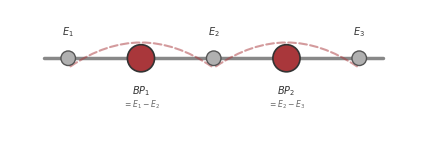

In [95]:
# --- Bipolar Reference Schematic Diagram ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14*cm, 4*cm))

# --- Parameters ---
n_actual = 3
spacing = 3.0
x_actual = np.arange(n_actual) * spacing  # actual electrode positions
y_strip = 0.0
actual_r = 0.15   # small radius for actual electrodes
virtual_r = 0.28  # larger radius for virtual electrodes
bp_color = red     # red for virtual electrodes
actual_color = '#B0B0B0'

# Virtual electrode positions (midpoints)
x_virtual = [(x_actual[i] + x_actual[i+1]) / 2 for i in range(n_actual - 1)]

# --- 1. Draw strip wire ---
ax.plot([x_actual[0] - 0.5, x_actual[-1] + 0.5], [y_strip, y_strip],
        color='#888888', linewidth=2.5, zorder=1, solid_capstyle='round')

# --- 2. Draw actual electrodes (gray, small) ---
for i, cx in enumerate(x_actual):
    circle = plt.Circle((cx, y_strip), actual_r,
                         fc=actual_color, ec='#555555', lw=1.0, zorder=3)
    ax.add_patch(circle)
    ax.text(cx, y_strip + actual_r + 0.25,
            f'$E_{{{i+1}}}$', ha='center', va='bottom', fontsize=7,
            color='#333333')

# --- 3. Draw virtual electrodes (red, large) + connections ---
for i, cx in enumerate(x_virtual):
    # Dashed lines from the two actual electrodes converging to virtual
    x1, x2 = x_actual[i], x_actual[i+1]

    arc = mpatches.FancyArrowPatch(
        (x1, y_strip - actual_r - 0.05),
        (x2, y_strip - actual_r - 0.05),
        connectionstyle="arc3,rad=-0.35",
        color=bp_color, lw=1.5, arrowstyle='-',
        linestyle='--', alpha=0.5,
        zorder=2,
    )
    ax.add_patch(arc)

    # Virtual electrode circle
    circle = plt.Circle((cx, y_strip), virtual_r,
                         fc=bp_color, ec='#333333', lw=1.2, zorder=4)
    ax.add_patch(circle)

    # Label inside or below the virtual electrode
    ax.text(cx, y_strip - virtual_r - 0.25,
            f'$BP_{{{i+1}}}$',
            ha='center', va='top', fontsize=7, fontweight='bold',
            color='#333333')
    ax.text(cx, y_strip - virtual_r - 0.55,
            f'$= E_{{{i+1}}} - E_{{{i+2}}}$',
            ha='center', va='top', fontsize=5.5, color='#666666')

# --- Layout ---
ax.set_xlim(x_actual[0] - 1.2, x_actual[-1] + 1.2)
ax.set_ylim(-1.5, 1.0)
ax.set_aspect('equal')
ax.axis('off')

fig.savefig('../img/fig1/fig1_bipolar_reference_schematic.svg',
            dpi=300, bbox_inches='tight')
plt.show()